In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 5-point Generator

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

plt.rcParams["figure.figsize"] = (7, 5)

Device: cpu


In [3]:
@dataclass
class StructuredGrid2D:
    nx: int
    ny: int
    lx: float
    ly: float
    thickness: float

    def __post_init__(self):
        self.n_cells = self.nx * self.ny
        self.dx = self.lx / self.nx
        self.dy = self.ly / self.ny
        self.bulk_volume = self.dx * self.dy * self.thickness
        self.face_i, self.face_j, self.face_area, self.face_distance = self._build_connectivity()
        self.cell_centers = self._build_centers()

    def cell_index(self, i, j):
        return i + self.nx * j

    def _build_centers(self):
        centers = np.zeros((self.n_cells, 2))
        for j in range(self.ny):
            for i in range(self.nx):
                c = self.cell_index(i, j)
                centers[c, 0] = (i + 0.5) * self.dx
                centers[c, 1] = (j + 0.5) * self.dy
        return centers

    def _build_connectivity(self):
        fi, fj, area, dist = [], [], [], []
        for j in range(self.ny):
            for i in range(self.nx):
                c = self.cell_index(i, j)
                if i + 1 < self.nx:
                    fi.append(c)
                    fj.append(self.cell_index(i + 1, j))
                    area.append(self.dy * self.thickness)
                    dist.append(self.dx)
                if j + 1 < self.ny:
                    fi.append(c)
                    fj.append(self.cell_index(i, j + 1))
                    area.append(self.dx * self.thickness)
                    dist.append(self.dy)
        return np.array(fi), np.array(fj), np.array(area, float), np.array(dist, float)

    def reshape(self, field):
        return np.asarray(field).reshape(self.ny, self.nx)

In [4]:
@dataclass
class CoreyFluid:
    mu_w: float = 1e-3
    mu_o: float = 4e-3
    s_wr: float = 0.20
    s_or: float = 0.25
    krw0: float = 0.30
    kro0: float = 1.00
    n_w: float = 2.0
    n_o: float = 2.0

    @property
    def s_min(self):
        return self.s_wr

    @property
    def s_max(self):
        return 1.0 - self.s_or

    def effective_saturation(self, sw):
        swe = (sw - self.s_wr) / (1.0 - self.s_wr - self.s_or)
        return np.clip(swe, 0.0, 1.0)

    def mobilities(self, sw):
        swe = self.effective_saturation(sw)
        krw = self.krw0 * swe ** self.n_w
        kro = self.kro0 * (1.0 - swe) ** self.n_o
        lam_w = krw / self.mu_w
        lam_o = kro / self.mu_o
        lam_t = lam_w + lam_o
        fw = lam_w / (lam_t + 1e-30)
        return lam_w, lam_o, lam_t, fw


class IMPES2D:
    def __init__(self, grid, phi=0.01, perm_mD=1.0):
        self.grid = grid
        self.phi = phi
        self.perm = perm_mD * 9.869233e-16
        self.fi = grid.face_i
        self.fj = grid.face_j
        self.T_geom = self.perm * grid.face_area / grid.face_distance

        self.rows_pattern = np.concatenate([self.fi, self.fj, np.arange(grid.n_cells)])
        self.cols_pattern = np.concatenate([self.fj, self.fi, np.arange(grid.n_cells)])

        self.inj = grid.cell_index(0, 0)
        self.prod = grid.cell_index(grid.nx - 1, grid.ny - 1)

        year = 365.0 * 24.0 * 3600.0
        pore_volume = phi * grid.lx * grid.ly * grid.thickness
        self.q_inj = 0.1 * pore_volume / year

        self.q_total = np.zeros(grid.n_cells)
        self.q_total[self.inj] = self.q_inj
        self.q_total[self.prod] = -self.q_inj
        self.gauge_cell = self.prod

    def pressure_solve(self, sw, fluid):
        _, _, lam_t, fw = fluid.mobilities(sw)
        lt_i = lam_t[self.fi]
        lt_j = lam_t[self.fj]
        lt_face = 2.0 * lt_i * lt_j / (lt_i + lt_j + 1e-30)
        T_face = self.T_geom * lt_face

        diag = np.zeros(self.grid.n_cells)
        np.add.at(diag, self.fi, T_face)
        np.add.at(diag, self.fj, T_face)

        data = np.concatenate([-T_face, -T_face, diag])
        A = sp.csr_matrix((data, (self.rows_pattern, self.cols_pattern)), shape=(self.grid.n_cells, self.grid.n_cells)).tolil()
        b = self.q_total.copy()

        # Gauge condition for no-flow pressure equation
        A[self.gauge_cell, :] = 0.0
        A[self.gauge_cell, self.gauge_cell] = 1.0
        b[self.gauge_cell] = 0.0

        p = spla.spsolve(A.tocsc(), b)
        F_total = -T_face * (p[self.fj] - p[self.fi])
        return p, F_total, fw

    def cfl_dt(self, F_total, cfl=0.5):
        outflux = np.zeros(self.grid.n_cells)
        np.add.at(outflux, self.fi, np.maximum(F_total, 0.0))
        np.add.at(outflux, self.fj, np.maximum(-F_total, 0.0))
        outflux += np.maximum(-self.q_total, 0.0)
        pv = self.phi * self.grid.bulk_volume
        return float(np.min(cfl * pv / np.maximum(outflux, 1e-30)))

    def transport_step(self, sw, F_total, fw, fluid, dt):
        upwind = np.where(F_total >= 0.0, self.fi, self.fj)
        Fw = fw[upwind] * F_total

        div = np.zeros(self.grid.n_cells)
        np.add.at(div, self.fi, Fw)
        np.add.at(div, self.fj, -Fw)

        q_w = np.zeros(self.grid.n_cells)
        q_w[self.inj] = self.q_inj
        q_w[self.prod] = fw[self.prod] * (-self.q_inj)

        pv = self.phi * self.grid.bulk_volume
        sw_new = sw + dt / pv * (q_w - div)
        return np.clip(sw_new, fluid.s_min, fluid.s_max)

    def run(self, n_w=2.0, n_o=2.0, final_years=20.0, n_save=41, cfl=0.5, max_dt_days=30.0):
        year = 365.0 * 24.0 * 3600.0
        final_time = final_years * year
        save_times = np.linspace(0.0, final_time, n_save)

        fluid = CoreyFluid(n_w=n_w, n_o=n_o)
        sw = np.full(self.grid.n_cells, fluid.s_min)

        saved_t, saved_sw, saved_p = [], [], []

        t = 0.0
        next_save = 0

        while next_save < len(save_times):
            target = save_times[next_save]
            while t < target - 1e-9:
                p, F, fw = self.pressure_solve(sw, fluid)
                dt = self.cfl_dt(F, cfl=cfl)
                dt = min(dt, max_dt_days * 86400.0, target - t)
                sw = self.transport_step(sw, F, fw, fluid, dt)
                t += dt

            p, F, fw = self.pressure_solve(sw, fluid)
            saved_t.append(t)
            saved_sw.append(sw.copy())
            saved_p.append(p.copy())
            next_save += 1

        return {
            "times": np.asarray(saved_t),
            "saturation": np.asarray(saved_sw),
            "pressure": np.asarray(saved_p),
            "n_w": n_w,
            "n_o": n_o,
        }

In [5]:
grid = StructuredGrid2D(nx=30, ny=30, lx=500.0, ly=500.0, thickness=50.0)
sim = IMPES2D(grid, phi=0.01, perm_mD=1.0)

param_train = [
    (2.0, 2.0),
    (2.0, 3.0),
    (3.0, 2.0),
    (3.0, 3.0),
    (4.0, 2.5),
    (2.5, 4.0),
]

solutions = []
for nw, no in param_train:
    print(f"Generating FV solution for n_w={nw}, n_o={no}")
    solutions.append(sim.run(n_w=nw, n_o=no, final_years=20.0, n_save=41))

print("Data generation finished.")

Generating FV solution for n_w=2.0, n_o=2.0
Generating FV solution for n_w=2.0, n_o=3.0
Generating FV solution for n_w=3.0, n_o=2.0
Generating FV solution for n_w=3.0, n_o=3.0
Generating FV solution for n_w=4.0, n_o=2.5
Generating FV solution for n_w=2.5, n_o=4.0
Data generation finished.


In [6]:

def build_dataset(solutions, grid, max_points_per_solution=25000):
    X_list, Y_list = [], []
    centers = grid.cell_centers
    x = centers[:, 0] / grid.lx
    y = centers[:, 1] / grid.ly
    T_final = 20.0 * 365.0 * 24.0 * 3600.0

    global_p_scale = max(max(np.max(np.abs(sol["pressure"])) for sol in solutions), 1.0)

    for sol in solutions:
        times = sol["times"]
        Sw = sol["saturation"]
        P = sol["pressure"] / global_p_scale

        X_sol, Y_sol = [], []
        for it, t in enumerate(times):
            nc = grid.n_cells
            X = np.stack([
                x,
                y,
                np.full(nc, t / T_final),
                np.full(nc, sol["n_w"]),
                np.full(nc, sol["n_o"]),
            ], axis=1)
            Y = np.stack([Sw[it], P[it]], axis=1)
            X_sol.append(X)
            Y_sol.append(Y)

        X_sol = np.vstack(X_sol)
        Y_sol = np.vstack(Y_sol)

        if len(X_sol) > max_points_per_solution:
            idx = np.random.choice(len(X_sol), max_points_per_solution, replace=False)
            X_sol = X_sol[idx]
            Y_sol = Y_sol[idx]

        X_list.append(X_sol)
        Y_list.append(Y_sol)

    X = np.vstack(X_list).astype(np.float32)
    Y = np.vstack(Y_list).astype(np.float32)

    return X, Y, global_p_scale

X, Y, pressure_scale = build_dataset(solutions, grid)
print("Dataset:", X.shape, Y.shape)
print("Pressure scale:", pressure_scale)

Dataset: (150000, 5) (150000, 2)
Pressure scale: 347715328.58612955


# Net part

In [7]:
# Normalize parameter inputs n_w,n_o to [0,1]
nw_min, nw_max = 2.0, 4.0
no_min, no_max = 2.0, 4.0

Xn = X.copy()
Xn[:, 3] = (Xn[:, 3] - nw_min) / (nw_max - nw_min)
Xn[:, 4] = (Xn[:, 4] - no_min) / (no_max - no_min)

dataset = TensorDataset(torch.tensor(Xn), torch.tensor(Y))
loader = DataLoader(dataset, batch_size=8192, shuffle=True)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden, depth, out_dim):
        super().__init__()

        
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        raw = self.net(x)

        # Sw in 0.20-0.75
        sw = 0.20 + (0.55 * torch.sigmoid(raw[:, 0:1]))

        # normalized pressure
        p = raw[:, 1:2]
        return torch.cat([sw, p], dim=1)

model = MLP(in_dim=5, hidden=128, depth=5, out_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

In [8]:

def initial_condition_loss(model, batch_size):
    x = torch.rand(batch_size, 1, device=device)
    y = torch.rand(batch_size, 1, device=device)
    t = torch.zeros(batch_size, 1, device=device)
    nw = torch.rand(batch_size, 1, device=device)
    no = torch.rand(batch_size, 1, device=device)
    inp = torch.cat([x, y, t, nw, no], dim=1)
    sw = model(inp)[:, 0:1]
    return torch.mean((sw - 0.20) ** 2)

def smoothness_loss(model, batch_size):
    inp = torch.rand(batch_size, 5, device=device)
    inp.requires_grad_(True)
    sw = model(inp)[:, 0:1]
    grad = torch.autograd.grad(
        sw, inp,
        grad_outputs=torch.ones_like(sw),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.mean(grad[:, 0:2] ** 2)

In [9]:
from tqdm.auto import tqdm
n_epochs = 250 # loss for 250 epochs - 8.39e-5, for 200 epochs - 7.87e-5. So model was a bit overlearned for 250.
loss_history = []

epoch_bar = tqdm(range(n_epochs), desc="train...", unit="epoch")

for epoch in epoch_bar:
    total = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        loss_sw = mse(pred[:, 0:1], yb[:, 0:1])
        loss_p = mse(pred[:, 1:2], yb[:, 1:2])
        loss_ic = initial_condition_loss(model, 1024)
        loss_sm = smoothness_loss(model, 512)
        loss = loss_sw + 0.1 * loss_p + 2.0 * loss_ic + 1e-4 * loss_sm

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * len(xb)
    avg = total / len(dataset)
    loss_history.append(avg)

    epoch_bar.set_postfix(loss=avg)
    if epoch == 1 or epoch % 25 == 0:
        print('epoch= ', epoch, 'loss= ', avg)


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
train...:   0%|          | 1/250 [00:02<10:20,  2.49s/epoch, loss=0.103]

epoch=  0 loss=  0.10262927874445915


train...:   1%|          | 2/250 [00:04<10:01,  2.43s/epoch, loss=0.0185]

epoch=  1 loss=  0.018541391907036305


train...:  10%|█         | 26/250 [01:00<08:33,  2.29s/epoch, loss=0.00177]

...

train...:  80%|████████  | 201/250 [08:08<02:00,  2.45s/epoch, loss=0.00011] 

epoch=  200 loss=  0.00010974837868784865


train...:  90%|█████████ | 226/250 [09:13<01:03,  2.65s/epoch, loss=8.07e-5] 

epoch=  225 loss=  8.07348228211049e-05


train...: 100%|██████████| 250/250 [10:13<00:00,  2.45s/epoch, loss=8.19e-5] 


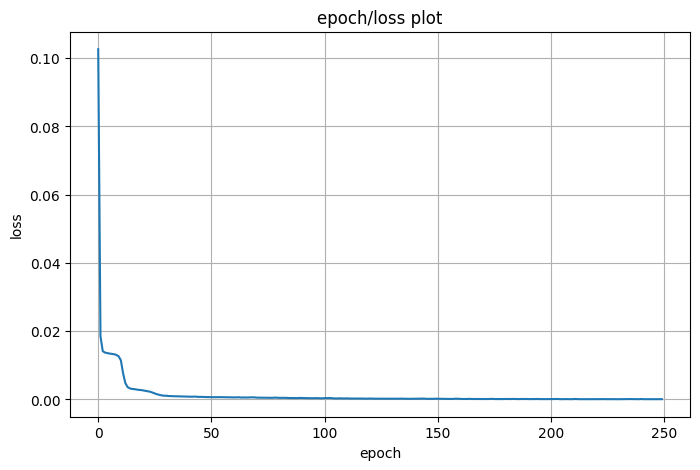

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(n_epochs), loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('epoch/loss plot')
plt.grid(True)
plt.show()

# Sobol coefficient

In [12]:
from SALib.sample import saltelli
from SALib.analyze import sobol

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_248852/798604395.py:12: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


sobol coeffs for Y_sw:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.003197  0.006076  0.005328  0.002167
4      x4  0.021464  0.043386  0.019743  0.007634
0      x0  0.071806  0.178543  0.032905  0.045103
1      x1  0.063677  0.209175  0.039829  0.051526
2      x2  0.642572  0.843365  0.111759  0.074492


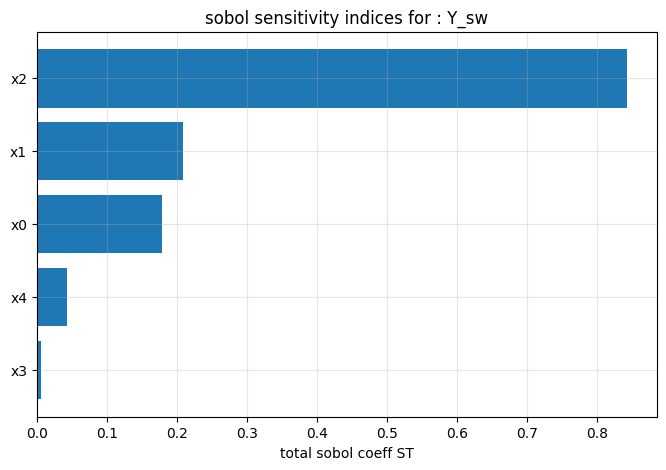

pairwise interactions S2 for  Y_sw
    x0        x1        x2        x3        x4
x0 NaN  0.019849  0.057131 -0.012727 -0.014200
x1 NaN       NaN  0.066994 -0.023786 -0.023146
x2 NaN       NaN       NaN  0.061885  0.071470
x3 NaN       NaN       NaN       NaN -0.003772
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------




sobol coeffs for Y_p:
  feature        S1        ST   S1_conf   ST_conf
3      x3  0.056574  0.094681  0.028510  0.012507
0      x0  0.104462  0.116930  0.030674  0.014256
1      x1  0.104626  0.119799  0.027726  0.017755
4      x4  0.221217  0.268491  0.048522  0.033404
2      x2  0.400293  0.495490  0.051809  0.047465


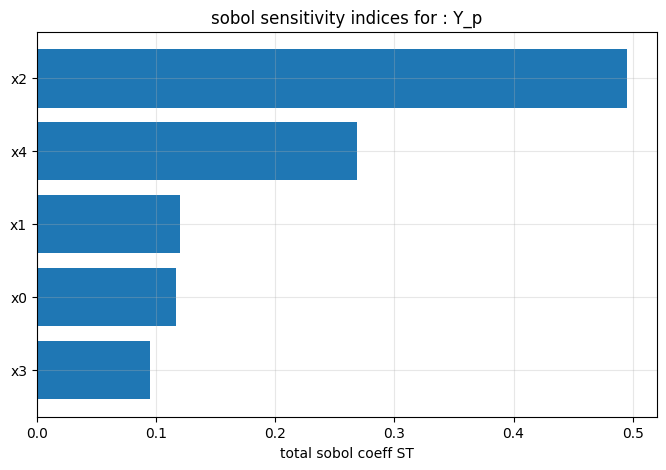

pairwise interactions S2 for  Y_p
    x0        x1        x2        x3        x4
x0 NaN  0.009884 -0.004318 -0.004445 -0.010652
x1 NaN       NaN  0.000926 -0.000270  0.000368
x2 NaN       NaN       NaN  0.038501  0.054235
x3 NaN       NaN       NaN       NaN -0.011499
x4 NaN       NaN       NaN       NaN       NaN

----------------------------------------






In [26]:
X_data = torch.cat([xb for xb, yb in loader], dim=0)#.detach().cpu().numpy()
features = ['x'+str(i) for i in range(X_data.shape[1])]

problem = {
    'num_vars': X_data.shape[1],
    'names': features,
    'bounds': [
        [X_data[:, i].min(), X_data[:, i].max()]
        for i in range(X_data.shape[1])]
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol = torch.tensor(param_values, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    Y_pred = model(X_sobol).detach().cpu().numpy()

Y_sw = Y_pred[:, 0]
Y_p = Y_pred[:, 1]

for y_tpl in ((Y_sw, 'Y_sw'), (Y_p, 'Y_p')):
    Si = sobol.analyze(problem, y_tpl[0], calc_second_order=True)
    sobol_df = pd.DataFrame({
        'feature': problem['names'],
        'S1': Si['S1'],
        'ST': Si['ST'],
        'S1_conf': Si['S1_conf'],
        'ST_conf': Si['ST_conf']})
    sobol_df_sorted = sobol_df.sort_values('ST')
    print(f'sobol coeffs for {y_tpl[1]}:')
    print(sobol_df.sort_values('ST'))

    plt.figure(figsize=(8, 5))
    plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
    plt.xlabel('total sobol coeff ST')
    plt.title(f'sobol sensitivity indices for : {y_tpl[1]}')
    plt.grid(True, alpha=0.3)
    plt.show()

    print('pairwise interactions S2 for ', y_tpl[1])
    print(pd.DataFrame(
        Si['S2'],
        index=problem['names'],
        columns=problem['names']
    ))
    print('\n----------------------------------------\n\n\n\n')